In [1]:
"""
Logistic Regression for Binary Classification
==============================================
Dataset: Breast Cancer Wisconsin (Diagnostic)
Task: Predict whether a tumor is Malignant (0) or Benign (1)

This is a complete end-to-end machine learning project demonstrating:
- Data loading and exploration
- Preprocessing and feature engineering
- Model training with logistic regression
- Comprehensive evaluation
- Visualization of results
"""

'\nLogistic Regression for Binary Classification\n==============================================\nDataset: Breast Cancer Wisconsin (Diagnostic)\nTask: Predict whether a tumor is Malignant (0) or Benign (1)\n\nThis is a complete end-to-end machine learning project demonstrating:\n- Data loading and exploration\n- Preprocessing and feature engineering\n- Model training with logistic regression\n- Comprehensive evaluation\n- Visualization of results\n'

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, roc_auc_score
)
import warnings
warnings.filterwarnings('ignore')

In [4]:
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print("="*80)
print("LOGISTIC REGRESSION FOR BINARY CLASSIFICATION")
print("Dataset: Breast Cancer Wisconsin (Diagnostic)")
print("="*80)

LOGISTIC REGRESSION FOR BINARY CLASSIFICATION
Dataset: Breast Cancer Wisconsin (Diagnostic)


In [5]:
# ============================================================================
# STEP 1: LOAD AND EXPLORE DATA
# ============================================================================
print("\n" + "="*80)
print("STEP 1: DATA LOADING AND EXPLORATION")
print("="*80)

# Load the breast cancer dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print(f"\n📊 Dataset Information:")
print(f"   Total samples: {len(X)}")
print(f"   Total features: {len(X.columns)}")
print(f"   Feature names: {list(X.columns[:5])}... (showing first 5)")

print(f"\n🎯 Target Variable:")
print(f"   Classes: {data.target_names}")
print(f"   Class 0 (Malignant): {sum(y == 0)} samples ({sum(y == 0)/len(y)*100:.1f}%)")
print(f"   Class 1 (Benign): {sum(y == 1)} samples ({sum(y == 1)/len(y)*100:.1f}%)")

print(f"\n📈 Data Quality:")
print(f"   Missing values: {X.isnull().sum().sum()}")
print(f"   Duplicate rows: {X.duplicated().sum()}")

print(f"\n📊 Feature Statistics (first 5 features):")
print(X.describe().iloc[:, :5].round(2))


STEP 1: DATA LOADING AND EXPLORATION

📊 Dataset Information:
   Total samples: 569
   Total features: 30
   Feature names: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']... (showing first 5)

🎯 Target Variable:
   Classes: ['malignant' 'benign']
   Class 0 (Malignant): 212 samples (37.3%)
   Class 1 (Benign): 357 samples (62.7%)

📈 Data Quality:
   Missing values: 0
   Duplicate rows: 0

📊 Feature Statistics (first 5 features):
       mean radius  mean texture  mean perimeter  mean area  mean smoothness
count       569.00        569.00          569.00     569.00           569.00
mean         14.13         19.29           91.97     654.89             0.10
std           3.52          4.30           24.30     351.91             0.01
min           6.98          9.71           43.79     143.50             0.05
25%          11.70         16.17           75.17     420.30             0.09
50%          13.37         18.84           86.24     551.10           


STEP 2: DATA VISUALIZATION


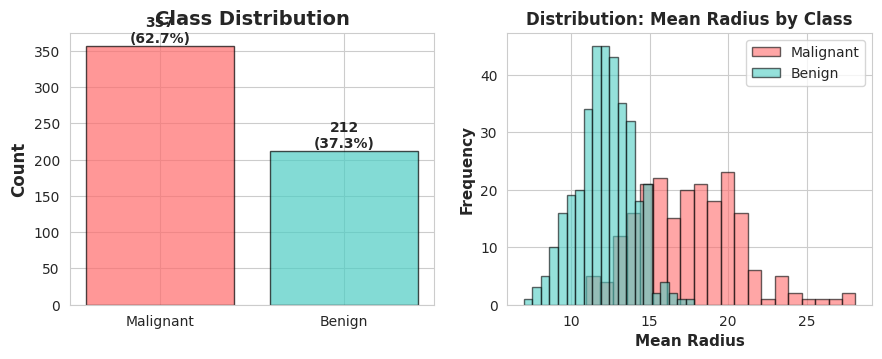

In [6]:
# ============================================================================
# STEP 2: DATA VISUALIZATION
# ============================================================================
print("\n" + "="*80)
print("STEP 2: DATA VISUALIZATION")
print("="*80)

# Create a figure with multiple subplots
fig = plt.figure(figsize=(16, 12))

# 1. Class Distribution
ax1 = plt.subplot(3, 3, 1)
class_counts = y.value_counts()
colors = ['#FF6B6B', '#4ECDC4']
bars = ax1.bar(['Malignant', 'Benign'], class_counts.values, color=colors, alpha=0.7, edgecolor='black')
ax1.set_ylabel('Count', fontsize=12, fontweight='bold')
ax1.set_title('Class Distribution', fontsize=14, fontweight='bold')
for bar in bars:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}\n({height/len(y)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold')

# 2. Feature Distribution - Mean Radius
ax2 = plt.subplot(3, 3, 2)
for target, color, label in zip([0, 1], colors, ['Malignant', 'Benign']):
    subset = X[y == target]['mean radius']
    ax2.hist(subset, bins=20, alpha=0.6, color=color, label=label, edgecolor='black')
ax2.set_xlabel('Mean Radius', fontsize=11, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax2.set_title('Distribution: Mean Radius by Class', fontsize=12, fontweight='bold')
ax2.legend()


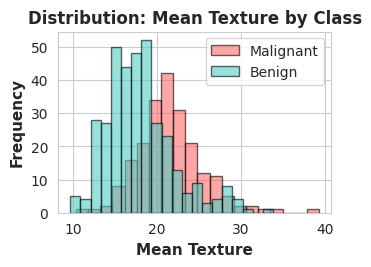

In [7]:
# 3. Feature Distribution - Mean Texture
ax3 = plt.subplot(3, 3, 3)
for target, color, label in zip([0, 1], colors, ['Malignant', 'Benign']):
    subset = X[y == target]['mean texture']
    ax3.hist(subset, bins=20, alpha=0.6, color=color, label=label, edgecolor='black')
ax3.set_xlabel('Mean Texture', fontsize=11, fontweight='bold')
ax3.set_ylabel('Frequency', fontsize=11, fontweight='bold')
ax3.set_title('Distribution: Mean Texture by Class', fontsize=12, fontweight='bold')
ax3.legend()

Text(0.5, 1.0, 'Box Plot: Mean Smoothness by Class')

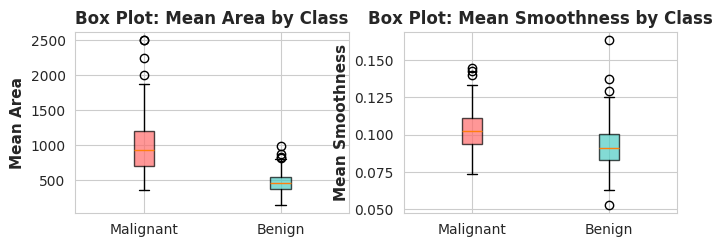

In [8]:
# 4. Box Plot - Mean Area
ax4 = plt.subplot(3, 3, 4)
box_data = [X[y == 0]['mean area'], X[y == 1]['mean area']]
bp = ax4.boxplot(box_data, labels=['Malignant', 'Benign'], patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax4.set_ylabel('Mean Area', fontsize=11, fontweight='bold')
ax4.set_title('Box Plot: Mean Area by Class', fontsize=12, fontweight='bold')

# 5. Box Plot - Mean Smoothness
ax5 = plt.subplot(3, 3, 5)
box_data = [X[y == 0]['mean smoothness'], X[y == 1]['mean smoothness']]
bp = ax5.boxplot(box_data, labels=['Malignant', 'Benign'], patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax5.set_ylabel('Mean Smoothness', fontsize=11, fontweight='bold')
ax5.set_title('Box Plot: Mean Smoothness by Class', fontsize=12, fontweight='bold')

Text(0.5, 1.0, 'Correlation Heatmap (Top 10 Features)')

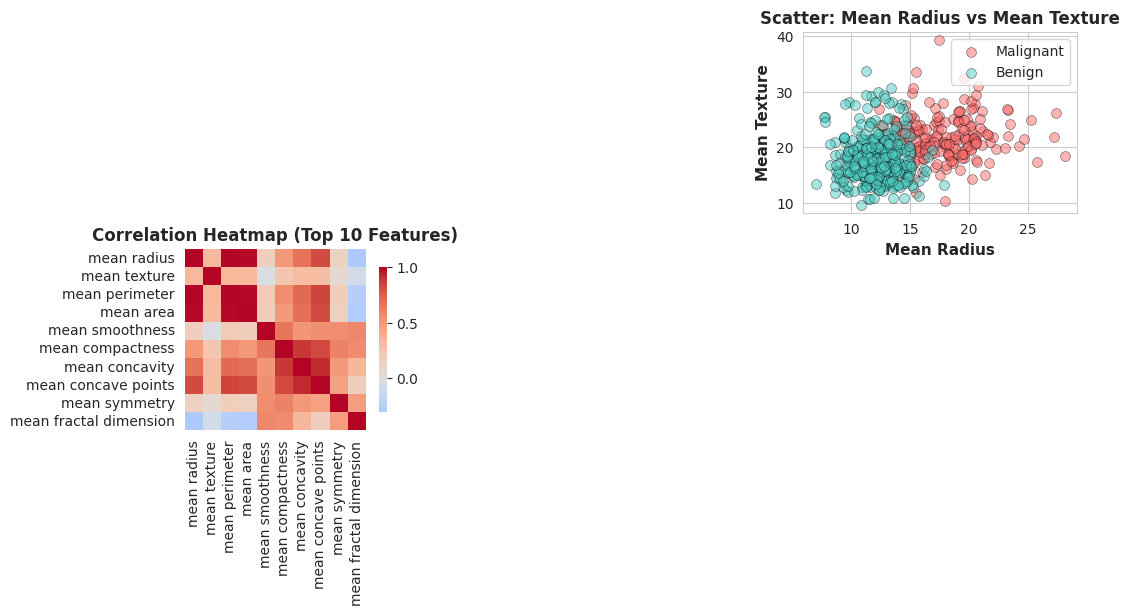

In [9]:
# 6. Scatter Plot - Mean Radius vs Mean Texture
ax6 = plt.subplot(3, 3, 6)
for target, color, label in zip([0, 1], colors, ['Malignant', 'Benign']):
    subset = X[y == target]
    ax6.scatter(subset['mean radius'], subset['mean texture'],
               c=color, label=label, alpha=0.5, s=50, edgecolors='black', linewidth=0.5)
ax6.set_xlabel('Mean Radius', fontsize=11, fontweight='bold')
ax6.set_ylabel('Mean Texture', fontsize=11, fontweight='bold')
ax6.set_title('Scatter: Mean Radius vs Mean Texture', fontsize=12, fontweight='bold')
ax6.legend()

# 7. Correlation Heatmap (top 10 features)
ax7 = plt.subplot(3, 3, 7)
top_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area',
                'mean smoothness', 'mean compactness', 'mean concavity',
                'mean concave points', 'mean symmetry', 'mean fractal dimension']
corr = X[top_features].corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0,
            square=True, ax=ax7, cbar_kws={'shrink': 0.8})
ax7.set_title('Correlation Heatmap (Top 10 Features)', fontsize=12, fontweight='bold')

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/01_data_exploration.png'

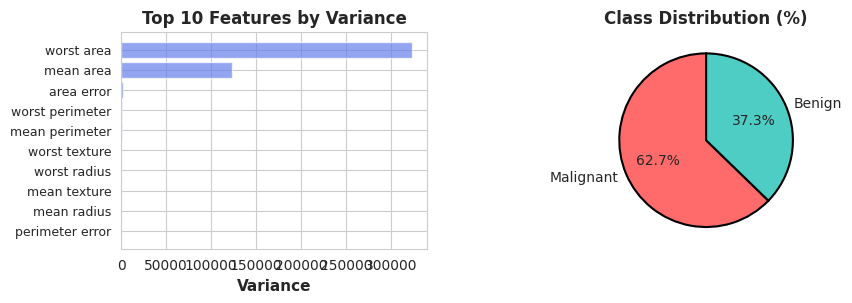

In [10]:
# 8. Feature Importance Preview (Variance)
ax8 = plt.subplot(3, 3, 8)
feature_variance = X.var().sort_values(ascending=False)[:10]
ax8.barh(range(len(feature_variance)), feature_variance.values, color='#667eea', alpha=0.7)
ax8.set_yticks(range(len(feature_variance)))
ax8.set_yticklabels([name[:20] for name in feature_variance.index], fontsize=9)
ax8.set_xlabel('Variance', fontsize=11, fontweight='bold')
ax8.set_title('Top 10 Features by Variance', fontsize=12, fontweight='bold')
ax8.invert_yaxis()

# 9. Class Balance Pie Chart
ax9 = plt.subplot(3, 3, 9)
ax9.pie(class_counts.values, labels=['Malignant', 'Benign'], autopct='%1.1f%%',
        colors=colors, startangle=90, wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
ax9.set_title('Class Distribution (%)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/mnt/user-data/outputs/01_data_exploration.png', dpi=300, bbox_inches='tight')
print("\n✅ Visualization saved: 01_data_exploration.png")
plt.close()

In [11]:
# ============================================================================
# STEP 3: DATA PREPROCESSING
# ============================================================================
print("\n" + "="*80)
print("STEP 3: DATA PREPROCESSING")
print("="*80)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📊 Data Split:")
print(f"   Training set: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Test set: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")
print(f"   Train class distribution: Malignant={sum(y_train==0)}, Benign={sum(y_train==1)}")
print(f"   Test class distribution: Malignant={sum(y_test==0)}, Benign={sum(y_test==1)}")

# Feature Scaling (Important for Logistic Regression!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n🔧 Feature Scaling Applied:")
print(f"   Method: StandardScaler (mean=0, std=1)")
print(f"   Training data mean: {X_train_scaled.mean():.6f}")
print(f"   Training data std: {X_train_scaled.std():.6f}")

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)



STEP 3: DATA PREPROCESSING

📊 Data Split:
   Training set: 455 samples (80.0%)
   Test set: 114 samples (20.0%)
   Train class distribution: Malignant=170, Benign=285
   Test class distribution: Malignant=42, Benign=72

🔧 Feature Scaling Applied:
   Method: StandardScaler (mean=0, std=1)
   Training data mean: -0.000000
   Training data std: 1.000000


In [12]:
# ============================================================================
# STEP 4: MODEL TRAINING
# ============================================================================
print("\n" + "="*80)
print("STEP 4: LOGISTIC REGRESSION MODEL TRAINING")
print("="*80)

# Create and train the logistic regression model
print("\n🤖 Training Logistic Regression Model...")
print("   Solver: lbfgs (Limited-memory BFGS)")
print("   Max iterations: 10000")
print("   Regularization: L2 (Ridge)")

logreg = LogisticRegression(
    random_state=42,
    max_iter=10000,
    solver='lbfgs'
)

# Train the model
logreg.fit(X_train_scaled, y_train)
print("   ✅ Model training completed!")

# Display model parameters
print(f"\n📊 Model Parameters:")
print(f"   Number of features: {logreg.n_features_in_}")
print(f"   Classes: {logreg.classes_}")
print(f"   Intercept: {logreg.intercept_[0]:.4f}")

# Get feature importance (coefficients)
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'coefficient': logreg.coef_[0]
}).sort_values('coefficient', key=abs, ascending=False)

print(f"\n🔝 Top 10 Most Important Features (by absolute coefficient):")
for idx, row in feature_importance.head(10).iterrows():
    direction = "↑ Increases" if row['coefficient'] > 0 else "↓ Decreases"
    print(f"   {row['feature'][:30]:30s}: {row['coefficient']:8.4f} ({direction} likelihood of Benign)")


STEP 4: LOGISTIC REGRESSION MODEL TRAINING

🤖 Training Logistic Regression Model...
   Solver: lbfgs (Limited-memory BFGS)
   Max iterations: 10000
   Regularization: L2 (Ridge)
   ✅ Model training completed!

📊 Model Parameters:
   Number of features: 30
   Classes: [0 1]
   Intercept: 0.3022

🔝 Top 10 Most Important Features (by absolute coefficient):
   worst texture                 :  -1.2551 (↓ Decreases likelihood of Benign)
   radius error                  :  -1.0830 (↓ Decreases likelihood of Benign)
   worst concave points          :  -0.9537 (↓ Decreases likelihood of Benign)
   worst area                    :  -0.9478 (↓ Decreases likelihood of Benign)
   worst radius                  :  -0.9476 (↓ Decreases likelihood of Benign)
   worst symmetry                :  -0.9392 (↓ Decreases likelihood of Benign)
   area error                    :  -0.9291 (↓ Decreases likelihood of Benign)
   worst concavity               :  -0.8232 (↓ Decreases likelihood of Benign)
   worst pe

In [13]:
# ============================================================================
# STEP 5: MODEL EVALUATION
# ============================================================================
print("\n" + "="*80)
print("STEP 5: MODEL EVALUATION")
print("="*80)

# Make predictions
y_train_pred = logreg.predict(X_train_scaled)
y_test_pred = logreg.predict(X_test_scaled)

# Get prediction probabilities
y_train_pred_proba = logreg.predict_proba(X_train_scaled)[:, 1]
y_test_pred_proba = logreg.predict_proba(X_test_scaled)[:, 1]

# Calculate metrics for training set
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_auc = roc_auc_score(y_train, y_train_pred_proba)

# Calculate metrics for test set
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_auc = roc_auc_score(y_test, y_test_pred_proba)

print("\n📊 Performance Metrics:")
print(f"\n   {'Metric':<20} {'Training':<15} {'Test':<15} {'Difference':<15}")
print(f"   {'-'*20} {'-'*15} {'-'*15} {'-'*15}")
print(f"   {'Accuracy':<20} {train_accuracy:<15.4f} {test_accuracy:<15.4f} {abs(train_accuracy-test_accuracy):<15.4f}")
print(f"   {'Precision':<20} {train_precision:<15.4f} {test_precision:<15.4f} {abs(train_precision-test_precision):<15.4f}")
print(f"   {'Recall':<20} {train_recall:<15.4f} {test_recall:<15.4f} {abs(train_recall-test_recall):<15.4f}")
print(f"   {'F1-Score':<20} {train_f1:<15.4f} {test_f1:<15.4f} {abs(train_f1-test_f1):<15.4f}")
print(f"   {'ROC-AUC':<20} {train_auc:<15.4f} {test_auc:<15.4f} {abs(train_auc-test_auc):<15.4f}")

# Check for overfitting
if abs(train_accuracy - test_accuracy) < 0.05:
    print(f"\n   ✅ Good generalization (difference < 5%)")
else:
    print(f"\n   ⚠️  Possible overfitting (difference >= 5%)")

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
print(f"\n📊 Confusion Matrix (Test Set):")
print(f"\n                  Predicted")
print(f"                  Malignant  Benign")
print(f"   Actual Malignant    {cm[0,0]:3d}      {cm[0,1]:3d}")
print(f"          Benign       {cm[1,0]:3d}      {cm[1,1]:3d}")

# Calculate additional metrics from confusion matrix
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
npv = tn / (tn + fn)  # Negative Predictive Value

print(f"\n📊 Additional Metrics:")
print(f"   True Negatives (TN):  {tn}")
print(f"   False Positives (FP): {fp}")
print(f"   False Negatives (FN): {fn}")
print(f"   True Positives (TP):  {tp}")
print(f"   Specificity:          {specificity:.4f}")
print(f"   Negative Pred. Value: {npv:.4f}")

# Classification Report
print(f"\n📋 Detailed Classification Report:")
print(classification_report(y_test, y_test_pred,
                          target_names=['Malignant', 'Benign'],
                          digits=4))



STEP 5: MODEL EVALUATION

📊 Performance Metrics:

   Metric               Training        Test            Difference     
   -------------------- --------------- --------------- ---------------
   Accuracy             0.9890          0.9825          0.0066         
   Precision            0.9861          0.9861          0.0000         
   Recall               0.9965          0.9861          0.0104         
   F1-Score             0.9913          0.9861          0.0052         
   ROC-AUC              0.9975          0.9954          0.0021         

   ✅ Good generalization (difference < 5%)

📊 Confusion Matrix (Test Set):

                  Predicted
                  Malignant  Benign
   Actual Malignant     41        1
          Benign         1       71

📊 Additional Metrics:
   True Negatives (TN):  41
   False Positives (FP): 1
   False Negatives (FN): 1
   True Positives (TP):  71
   Specificity:          0.9762
   Negative Pred. Value: 0.9762

📋 Detailed Classification Report:
